In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
## Loading the dataset
def load_data(file_path):
    return pd.read_csv(file_path)

In [10]:
df = load_data(r"C:\AHAMMED\BIA_DATA_SCIENCE\FIRST_PROJECT\MACHINE_LEARNING\DATASET\Housing.csv")

EDA

In [15]:
def basic_info(df):
    print(df.head())
    print(df.shape)
    print(df.info())
    print(df.describe())

Missing Values

In [16]:
def check_missing_values(df):
    print(df.isnull().sum())

In [17]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [18]:
##Correlation Analysis
def correlation_matrix(df):
    return df.corr(numeric_only=True)

In [20]:
corr_matrix = correlation_matrix(df)

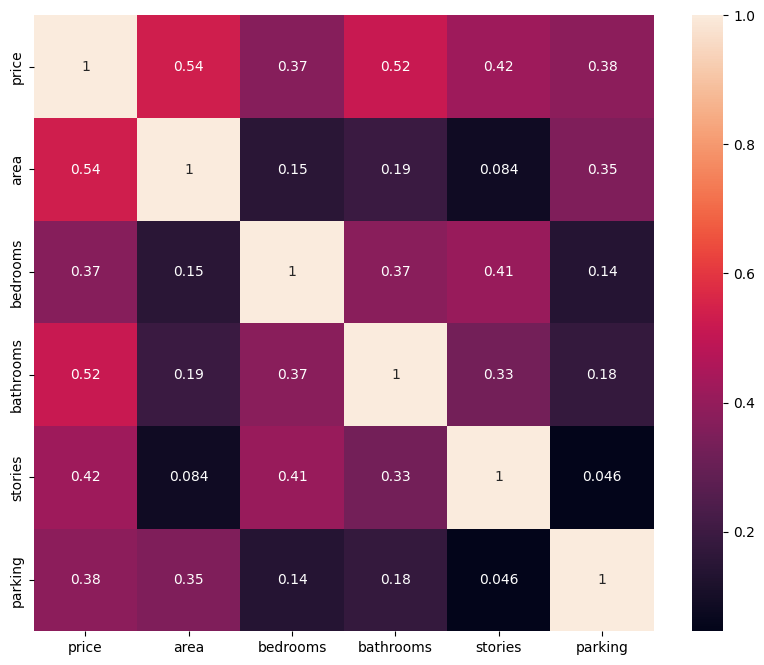

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [22]:
## Feature Engineering
def encode_features(df):

    binary_cols = [
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'prefarea'
    ]

    for col in binary_cols:
        df[col] = df[col].map({'yes':1,'no':0})

    df = pd.get_dummies(
        df,
        columns=['furnishingstatus'],
        drop_first=True
    )

    return df

In [23]:
def split_features_target(df):

    X = df.drop('price', axis=1)

    y = df['price']

    return X,y

In [24]:
## Train Test Split
from sklearn.model_selection import train_test_split

def split_data(X,y):

    return train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

In [25]:
## Standardization

from sklearn.preprocessing import StandardScaler

def scale_data(X_train,X_test):

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled,X_test_scaled

In [26]:
## Model Training
from sklearn.linear_model import LinearRegression

def train_model(X_train,y_train):

    model = LinearRegression()

    model.fit(X_train,y_train)

    return model

In [28]:
##Prediction
def predict(model,X_test):
    return model.predict(X_test)

In [30]:
##Evaluation
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

def evaluate(y_test,predictions):

    print("R2 Score:", r2_score(y_test,predictions))

    print("MSE:", mean_squared_error(y_test,predictions))

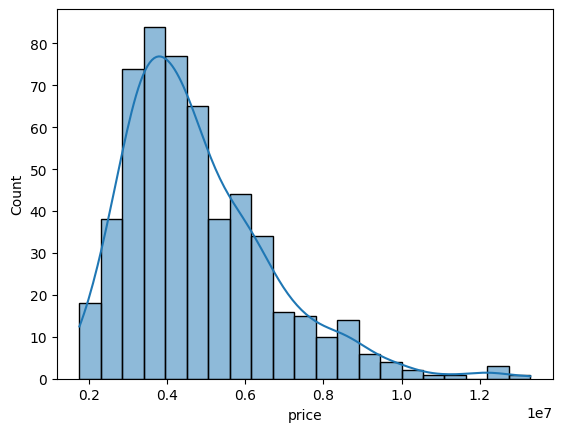

In [ ]:
##Price Distribution
sns.histplot(df['price'], kde=True)
plt.show()

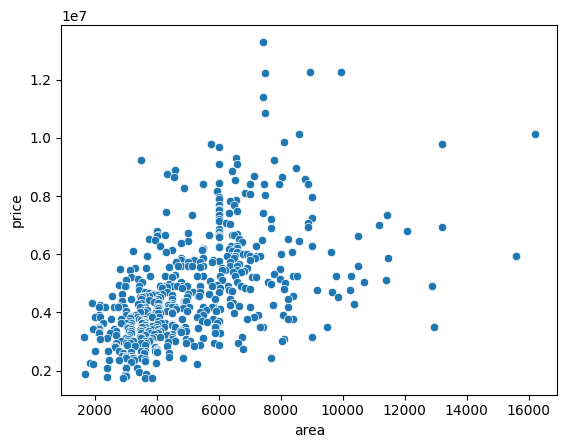

In [32]:
## Area vs Price
sns.scatterplot(
    x='area',
    y='price',
    data=df
)
plt.show()

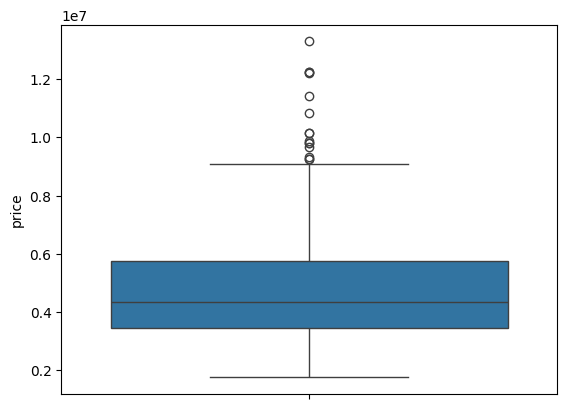

In [33]:
## Boxplot (Outlier Detection)
sns.boxplot(df['price'])
plt.show()

In [37]:
def correlation_matrix(df):
    return df.corr(numeric_only=True)

In [38]:
corr = correlation_matrix(df)

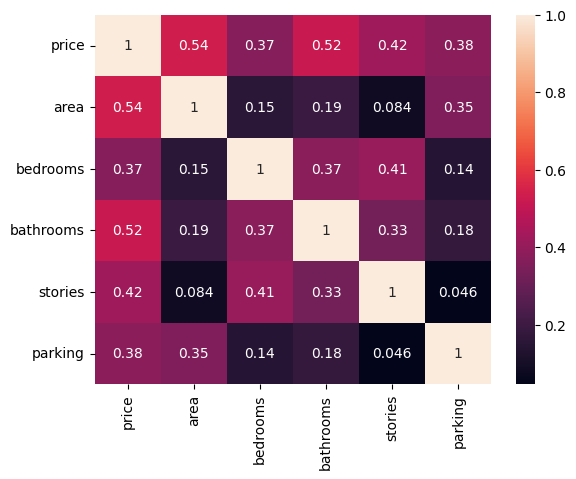

In [39]:
sns.heatmap(corr, annot=True)
plt.show()